In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid")

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['class'] = df['target'].map({0: 'Class 0', 1: 'Class 1', 2: 'Class 2'})

print(df.shape)
df.head()

(178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class 0


In [3]:
print(df.info())
print("\n--- Описательная статистика ---")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [4]:
print("Пропуски:")
print(df.isnull().sum())

print("\nРаспределение классов:")
print(df['class'].value_counts())

Пропуски:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
class                           0
dtype: int64

Распределение классов:
class
Class 1    71
Class 0    59
Class 2    48
Name: count, dtype: int64


C:\Users\kakad\AppData\Local\Temp\ipykernel_20348\498261230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')


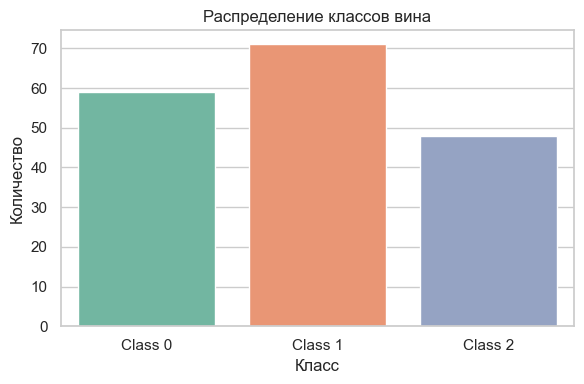

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette='Set2')
plt.title('Распределение классов вина')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150)
plt.show()

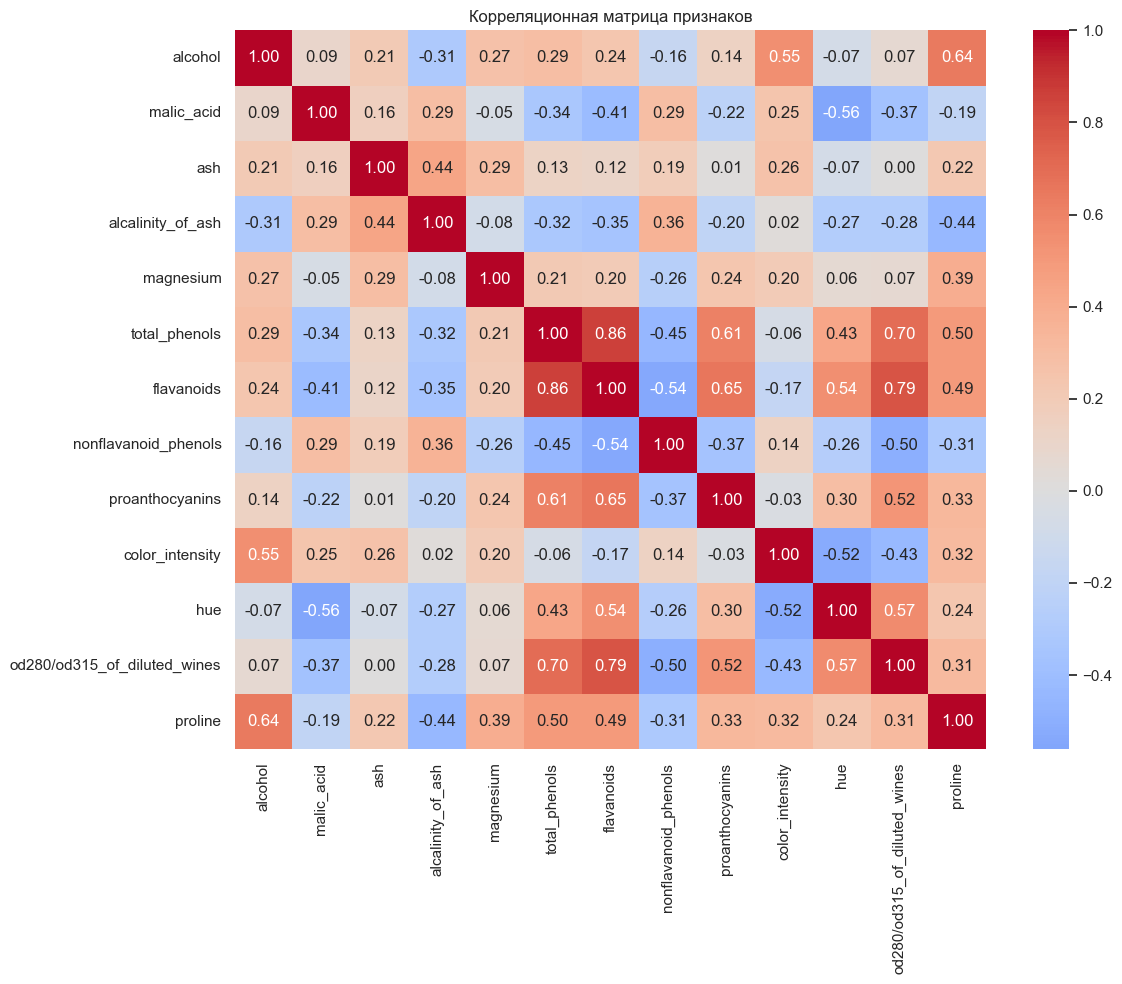

In [6]:
plt.figure(figsize=(12, 10))
corr = df.drop(columns=['target', 'class']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.savefig('../plots/correlation_matrix.png', dpi=150)
plt.show()

C:\Users\kakad\AppData\Local\Temp\ipykernel_20348\1516156368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=feat, palette='Set2', ax=axes[i])
C:\Users\kakad\AppData\Local\Temp\ipykernel_20348\1516156368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=feat, palette='Set2', ax=axes[i])
C:\Users\kakad\AppData\Local\Temp\ipykernel_20348\1516156368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=feat, palette='Set2', ax=axes[i])
C:\Users\kakad\AppData\Local\Temp\ipyker

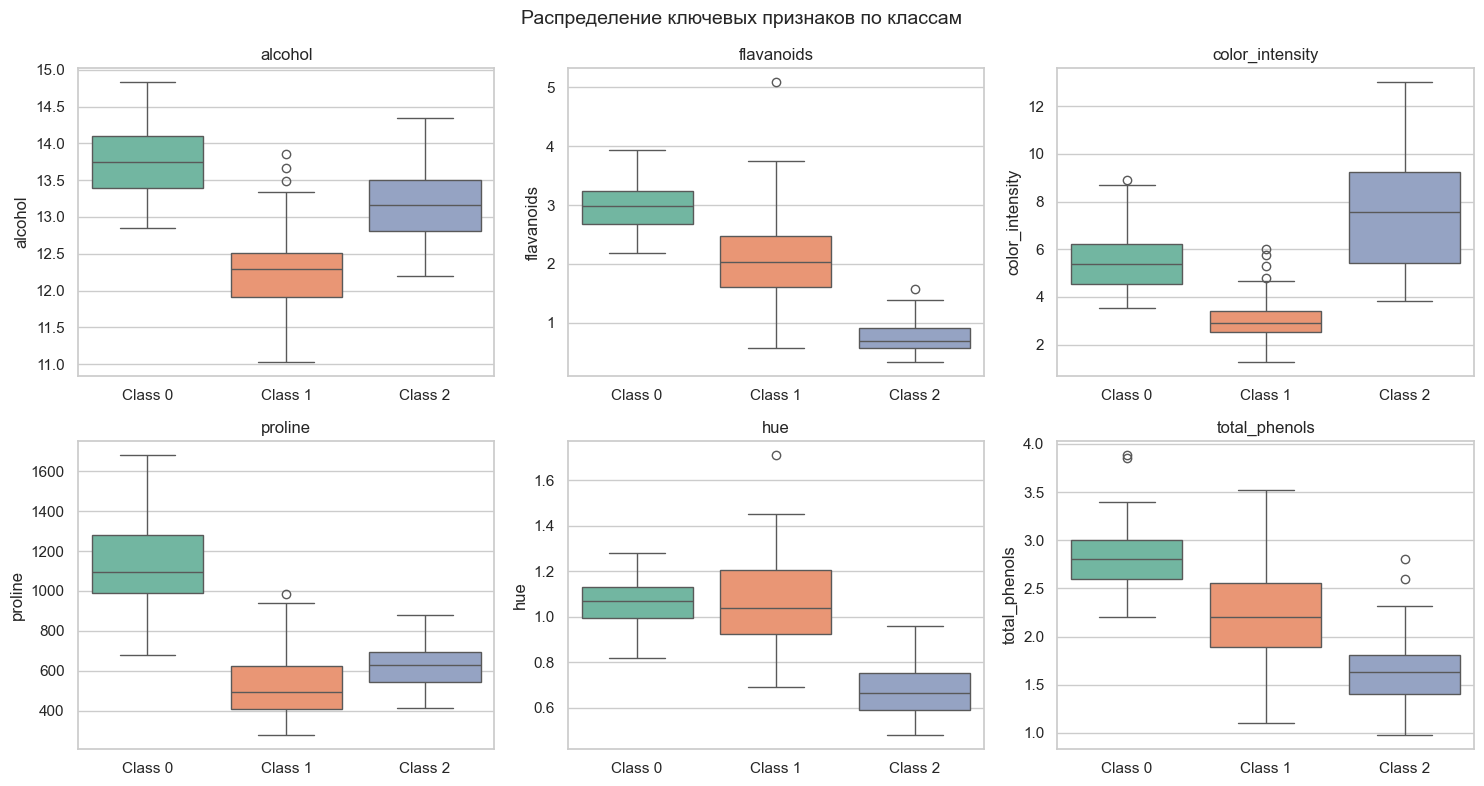

In [7]:
features = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'hue', 'total_phenols']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='class', y=feat, palette='Set2', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.suptitle('Распределение ключевых признаков по классам', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boxplot_features.png', dpi=150)
plt.show()

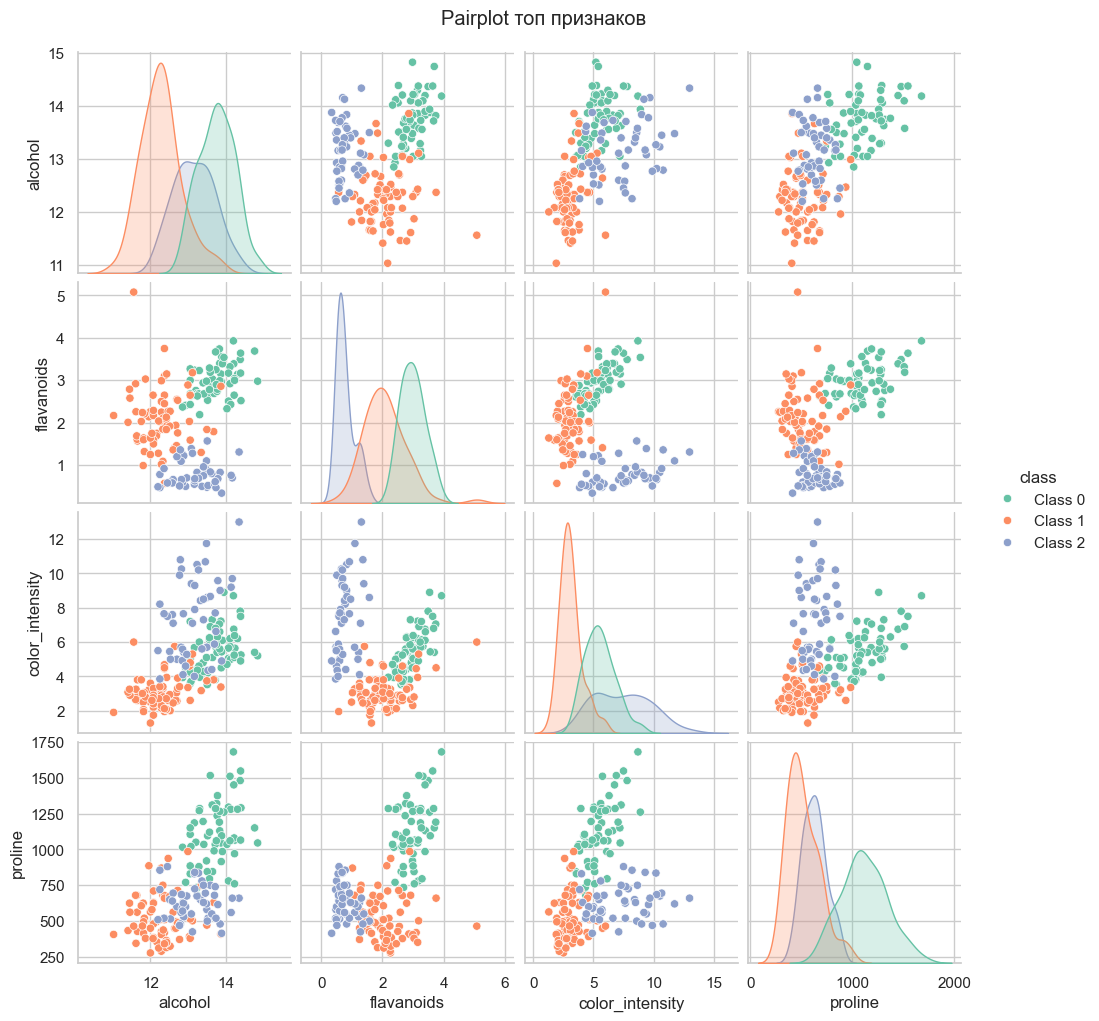

In [8]:
top_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'class']
sns.pairplot(df[top_features], hue='class', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot топ признаков', y=1.02)
plt.savefig('../plots/pairplot.png', dpi=150)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target', 'class'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (142, 13), Test: (36, 13)


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True
)
rf.fit(X_train, y_train)

print(f"OOB Score: {rf.oob_score_:.4f}")

OOB Score: 0.9789


In [11]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba, multi_class='ovr'):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Accuracy:  1.0000
ROC-AUC:   1.0000
OOB Score: 0.9789

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



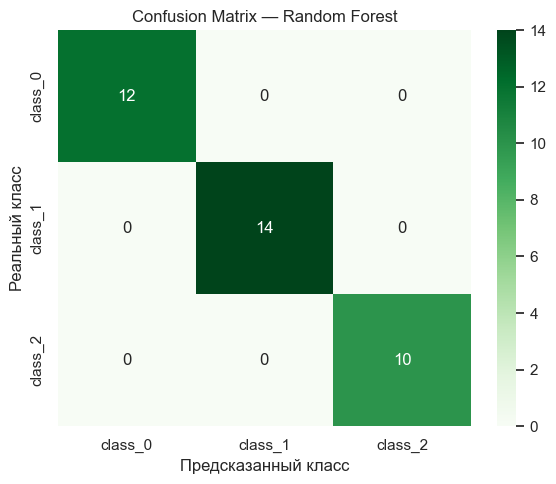

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig('../plots/confusion_matrix.png', dpi=150)
plt.show()

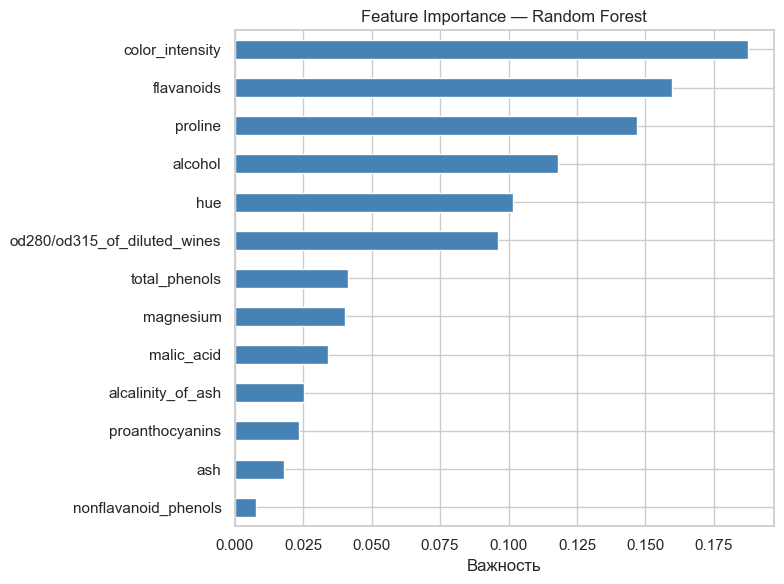

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('../plots/feature_importance.png', dpi=150)
plt.show()

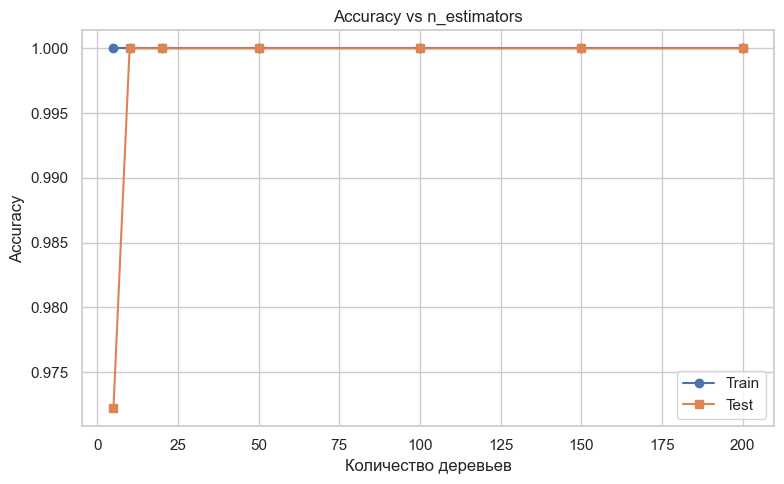

In [14]:
from sklearn.metrics import accuracy_score

n_estimators_range = [5, 10, 20, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_scores, marker='o', label='Train')
plt.plot(n_estimators_range, test_scores, marker='s', label='Test')
plt.title('Accuracy vs n_estimators')
plt.xlabel('Количество деревьев')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/learning_curve.png', dpi=150)
plt.show()

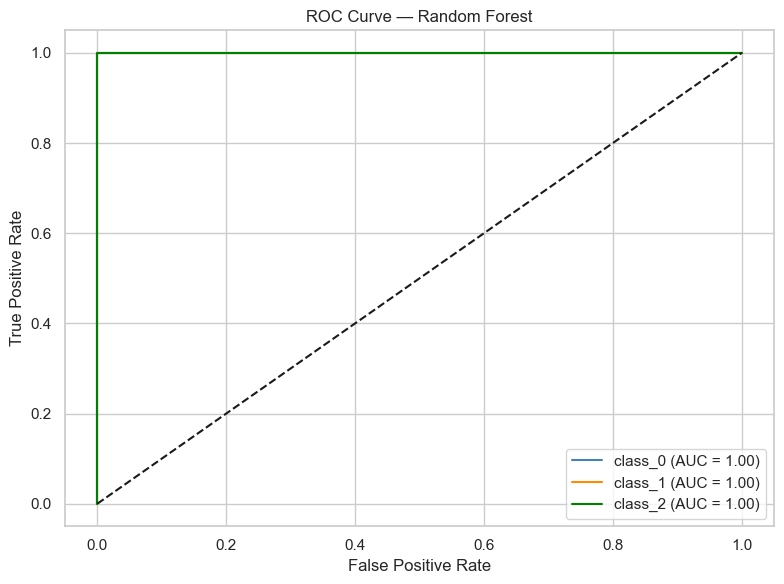

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 6))
for i, (color, name) in enumerate(zip(colors, wine.target_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve — Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/roc_curve.png', dpi=150)
plt.show()

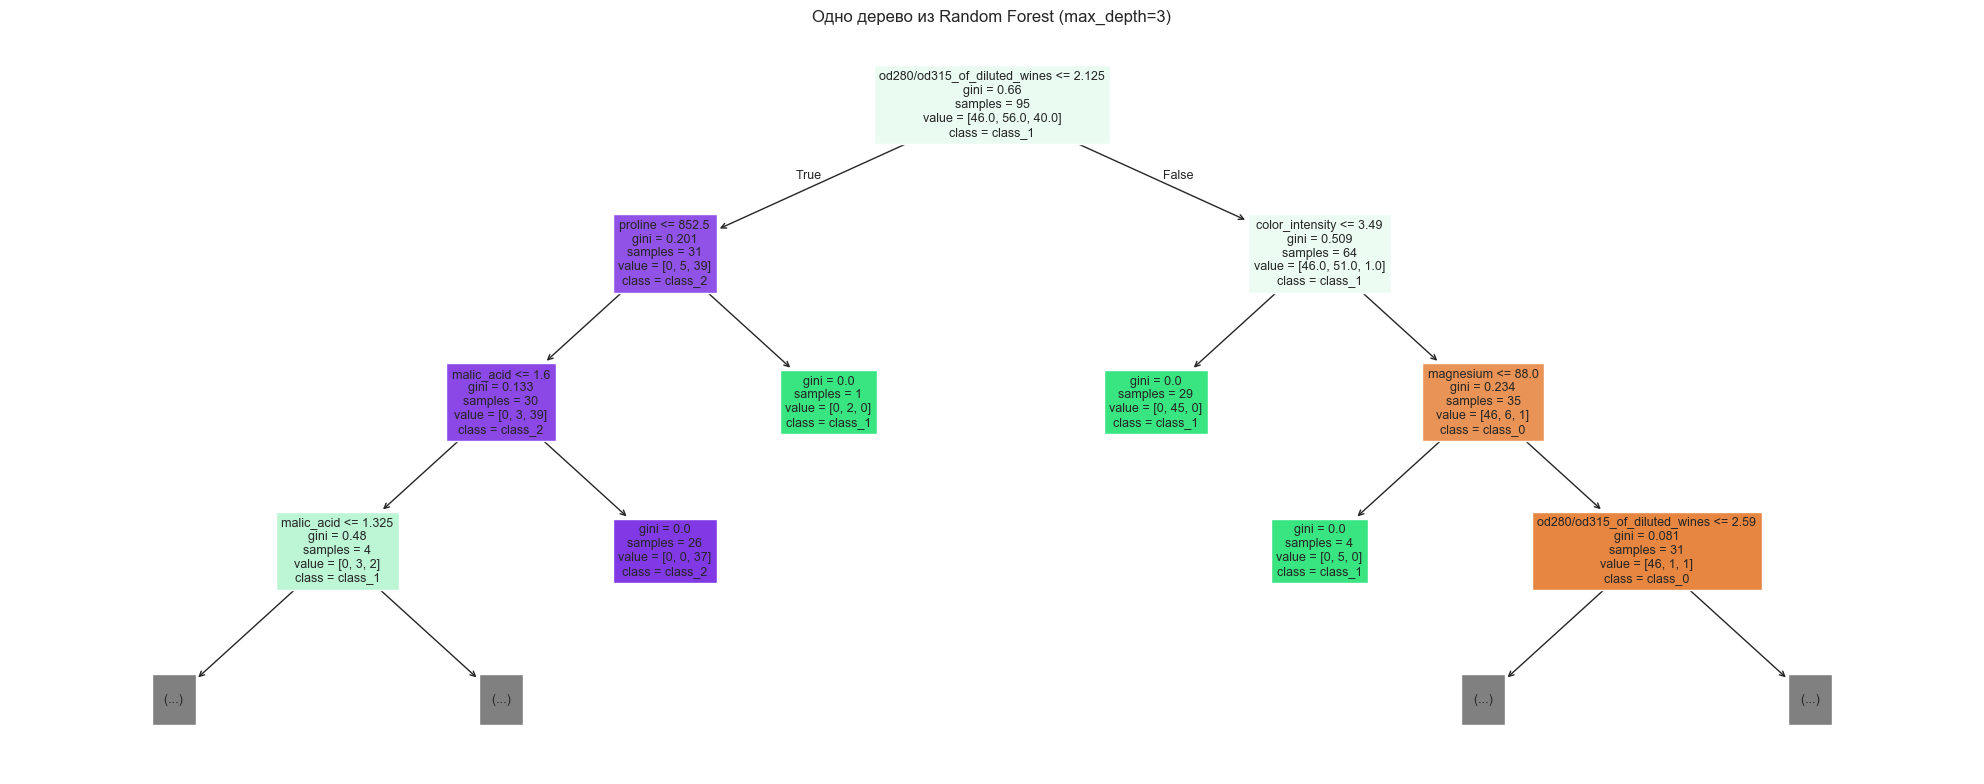

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns.tolist(),
    class_names=wine.target_names.tolist(),
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Одно дерево из Random Forest (max_depth=3)')
plt.tight_layout()
plt.savefig('../plots/single_tree.png', dpi=150)
plt.show()

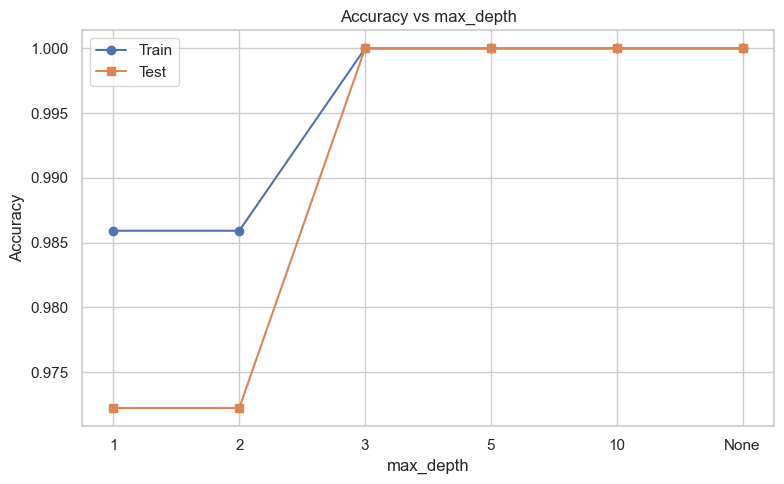

In [17]:
depths = [1, 2, 3, 5, 10, None]
depth_labels = ['1', '2', '3', '5', '10', 'None']
train_scores, test_scores = [], []

for d in depths:
    model = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_scores, marker='o', label='Train')
plt.plot(depth_labels, test_scores, marker='s', label='Test')
plt.title('Accuracy vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/depth_curve.png', dpi=150)
plt.show()

In [18]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print("Модель сохранена в models/rf_model.pkl")
print(f"Признаки: {X.columns.tolist()}")

Модель сохранена в models/rf_model.pkl
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
